In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.compute as pc
from adam_core.time import Timestamp
from astropy.time import Time
import matplotlib.pyplot as plt
import quivr as qv
import numpy as np
import requests
from typing import Dict, Tuple
from adam_core.constants import DE44X_CONSTANTS

In [2]:
all_data = pq.read_table("../data/paper_data.parquet")

In [3]:
all_data = all_data.sort_by("obstime")

In [4]:
def subset_data(object_id: str, data: pa.Table) -> Tuple[pa.Table, pa.DoubleArray, Dict[str, pa.DoubleArray], Dict[str, pa.DoubleArray]]:
    """Pulls data for the given object from the collection of all data
    
    Returns:
    --------
    obs_time: DoubleArray
      All observation times for the given object as MJD, sorted ascending
    otime: dict[str, Timestamp]
      Dictionary from band color to timestamps for it
    mag: dict[str, DoubleArray]
      Dictionary from band color to magnitudes for it
    """
    selection = data.filter(pc.equal(data["provid"], object_id))
    obs_time = Timestamp.from_astropy(Time(selection["obstime"].to_pylist())).mjd()
    arc_len = pc.max(obs_time).as_py() - pc.min(obs_time).as_py()
    mag = {}
    otime = {}
    # TODO: also "u"? And see other 'spellings' of same 4 colors
    for color in ["g", "i", "r"]:
        mag[color] = selection.filter(pc.equal(selection["band"], color))["mag"].cast('float')
        otime[color] = Timestamp.from_astropy(Time(selection.filter(pc.equal(selection["band"], color))["obstime"]))
    mean_mag_r = pc.mean(mag["r"])
    delta_mag_r = pc.max(mag["r"]).as_py() - pc.min(mag["r"]).as_py()
    print(f"For object {object_id}: num obs {len(selection)}, arc length {arc_len}")
    print(f"Mean mag in r-band {mean_mag_r}, delta mag in r-band {delta_mag_r}")
    print(f"Counts per band: g {len(mag['g'])}, i {len(mag['i'])}, r {len(mag['r'])}")
    assert np.sum([len(v) for v in mag.values()]) == len(selection), "Add missing colors"
    return selection, obs_time, otime, mag

In [5]:
# Pick an object from the paper "2025 MM81"
# should have mag variation 1.2, period 0.045 days ~= 1.1h
# from page 11 of the paper for 2025MM81:
# H mag = 21.1, mean mag r-band = 22.90, num obs=390, arc (days) 9,
# period (LSM/Furier) 1.1/1.1,
# Amplitude LSM/Furier 1.0/1.2, g-r LSM/Furier 0.55/0.53, g-i LSM/Furier 0.67/0.66,
# r-i LSM/Furier 0.12/0.12, axial elongation 2.1
mm81_id = "2025 MM81"
mm81_selection, mm81_obstime, mm81_otime, mm81_mag = subset_data(mm81_id, all_data)

For object 2025 MM81: num obs 390, arc length 9.035824999999022
Mean mag in r-band 22.902367843978706, delta mag in r-band 1.4479999542236328
Counts per band: g 127, i 89, r 174


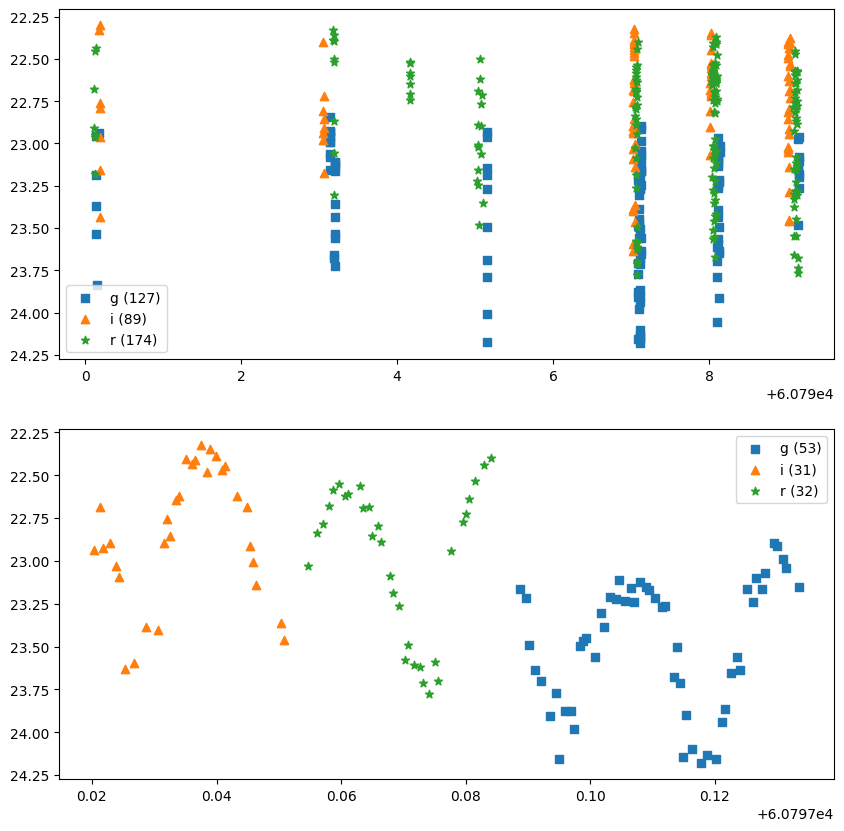

In [ ]:
# Repro Figure 8 from the paper
def show_figure8(obs_time, otime, mag, first_day: float):
    """Draw figure similar to Figure8 in the paper.
    Parameters:
    -----------
    obs_time:
      sorted list of all observation times for the given object

    """
    # print(pc.min(otime["g"].mjd()), pc.max(otime["g"].mjd()))
    _fig, axs = plt.subplots(2, 1, figsize=(10, 10))
    axs[0].scatter(otime["g"].mjd().to_pylist(), mag["g"].to_pylist(), marker="s", c="tab:blue", label=f"g ({len(mag['g'])})")
    axs[0].scatter(otime["i"].mjd().to_pylist(), mag["i"].to_pylist(), marker="^", c="tab:orange", label=f"i ({len(mag['i'])})")
    axs[0].scatter(otime["r"].mjd().to_pylist(), mag["r"].to_pylist(), marker="*", c="tab:green", label=f"r ({len(mag['r'])})")
    axs[0].legend()
    axs[0].invert_yaxis()

    # Find the night with the observation count matching Figure 8 in the paper
    beginning_of_time = pc.min(obs_time).as_py() - 0.25
    start_time = beginning_of_time + first_day # 6 is the number that matched the count
    end_time = start_time + 1.5 # make sure to get the whole night

    selected_times = {}
    selected_mags = {}
    for color in ["g", "i", "r"]:
        index = pc.and_(pc.greater(otime[color].mjd(), start_time), pc.less(otime[color].mjd(), end_time))
        selected_times[color] = otime[color].mjd().to_numpy()[index]
        selected_mags[color] = mag[color].to_numpy()[index]
    axs[1].scatter(selected_times["g"], selected_mags["g"], marker="s", c="tab:blue", label=f"g ({len(selected_mags['g'])})")
    axs[1].scatter(selected_times["i"], selected_mags["i"], marker="^", c="tab:orange", label=f"i ({len(selected_mags['i'])})")
    axs[1].scatter(selected_times["r"], selected_mags["r"], marker="*", c="tab:green", label=f"r ({len(selected_mags['r'])})")
    axs[1].legend()
    axs[1].invert_yaxis()

    plt.show()

show_figure8(mm81_obstime, mm81_otime, mm81_mag, 6)

In [18]:
# Page 6: "heliocentric and topocentric distances, r and Δ, respectively, as well as the
# phase angles, α, were obtained via the NASA Horizons API"
class RotationalPeriodInput(qv.Table):
    object_id = qv.LargeStringColumn()
    obs_time = Timestamp.as_column()
    sun_range = qv.Float64Column()
    obs_range = qv.Float64Column()
    angle = qv.Float64Column()

def _parse_rotational_period_input_response(object_id: str, text: str) -> RotationalPeriodInput:
    lines = text.splitlines()
    row = 0
    while row < len(lines) and not lines[row].startswith("$$SOE"):
        row += 1
    row += 1
    jd = []
    sun_range = []
    obs_range = []
    angle = []
    while row < len(lines) and not lines[row].startswith("$$EOE"):
        parts = lines[row].split(",")
        # text date, JD data, solar presence, lunar presence, sun range to target AU,
        # observer range to target AU, Sun-Target-Observer angle degrees, <-- extra comma
        assert len(parts) >= 7, f"Actual length {len(parts)}: {parts}"
        jd.append(float(parts[1]))
        sun_range.append(float(parts[4]))
        obs_range.append(float(parts[5]))
        angle.append(float(parts[6]))
        row += 1
    return RotationalPeriodInput.from_kwargs(
        object_id = [object_id] * len(jd),
        obs_time = Timestamp.from_jd(jd),
        sun_range = sun_range,
        obs_range = obs_range,
        angle = angle,
    )


def _query_rotational_period_inputs(object_id: str, stn: str, obs_times: pa.DoubleArray) -> RotationalPeriodInput:
    API_URL = "https://ssd.jpl.nasa.gov/api/horizons.api"
    chunk_size = 30 # 100 is too much
    start_chunk = 0
    sess = requests.Session() # TODO: parallel queries?
    # Selected: 
    # "19: heliocentric range and range rate"
    # "20: observer range and range rate"
    # "24: Sun-target-observer ~PHASE angle"
    # Suppress rates, only use ranges
    params = {
        "format": "text",
        "COMMAND": f"'DES={object_id};'",
        "OBJ_DATA": "NO", # default YES
        # "MAKE_EPHEM": "YES", # default
        #"EPHEM_TYPE": "OBSERVER", # default
        "CENTER": stn,
        "TIME_TYPE": "UT",
        "TLIST_TYPE": "MJD",
        "QUANTITIES": "'19,20,24'",
        "CAL_FORMAT": "BOTH", # CAL & JD
        "CSV_FORMAT": "YES",
        # "RANGE_UNITS": "AU", # default
        "SUPPRESS_RANGE_RATE": "YES", # default NO
    }
    collections = []
    while start_chunk < len(obs_times):
        tlist = [f"'{v}'" for v in obs_times[start_chunk:start_chunk+chunk_size]]
        start_chunk += chunk_size
        params["TLIST"] = " ".join(tlist)
        resp = sess.get(
            API_URL, params=params, timeout=10
        )
        resp.raise_for_status()
        collections.append(_parse_rotational_period_input_response(object_id, resp.text))
    return qv.concatenate(collections)

def cache_or_query_rotational_period_inputs(object_id: str,
                                            stn: str,
                                            obs_times: pa.DoubleArray,
                                            cache_file: str = "../data/rot_period_inputs.parquet",
                                            force_query: bool = False) -> RotationalPeriodInput:
    
    try:
        input_data = RotationalPeriodInput.from_parquet(cache_file)
        print(f"Read total {len(input_data)} records")
    except:
        print(f"Failed to read {cache_file}")
        input_data = RotationalPeriodInput.empty()
    result = input_data.apply_mask(pc.equal(input_data.object_id, object_id))
    if force_query or len(result) == 0:
        print(f"Query API for {object_id} and {len(obs_times)} timestamps")
        result = _query_rotational_period_inputs(object_id, stn, obs_times)
        input_data = qv.concatenate([
            input_data.apply_mask(pc.not_equal(input_data.object_id, object_id)),
            result,
            ])
        input_data.to_parquet(cache_file)
    return result


In [20]:
mm81_inputs = cache_or_query_rotational_period_inputs(mm81_id, "X05", mm81_obstime)
mm81_inputs

Read total 390 records


RotationalPeriodInput(size=390)

In [ ]:
# High-order Fourier Analysis

def _adjust_inputs_for_fourier(observation_table: pa.Table, range_inputs: RotationalPeriodInput,
                              obs_time: pa.DoubleArray) -> Tuple[np.ndarray, np.ndarray]:
    # Sanity that the arrays are sorted, so we can just match indexes
    deltas = pc.subtract(obs_time, range_inputs.obs_time.mjd())
    assert pc.max(pc.abs(deltas)).as_py() < 1e-9

    observed_mags = np.array([float(v) for v in observation_table["mag"]])
    helio_r = range_inputs.sun_range.to_numpy()
    topo_delta = range_inputs.obs_range.to_numpy()
    alpha = range_inputs.angle.to_numpy()
    print(f"Alpha range {np.min(alpha)} - {np.max(alpha)}")

    # Page 6, section 3.1
    # Subtract 5*log10(r*delta) from observational magnitudes
    # print(f"Sizes V={observed_mags.shape}, r={helio_r.shape}, delta={topo_delta.shape}, alpha={alpha.shape}")
    observed_mags = observed_mags - 5*np.log10(helio_r * topo_delta)

    # Correct timing for speed of light: t = t_obs - delta/c
    observed_time = obs_time - topo_delta / DE44X_CONSTANTS["C"]
    return observed_time, observed_mags

def _fit_fourier(freq: float, k: int, obs_v, obs_t, alpha, bands, weights) -> Tuple[np.ndarray, float, int]:
    # return values, sigma2, np.sum(included)


    # Model phi(alpha) = c1*alpha + c2*alpha^2
    # g (t ) = sum(j=1:k) Aj*cos (2 fjt ) + Bj*sin (2 fjt ) for k 2:6
    # X=[c1, c2, A1, B1, ..., Ak, Bk, Hg, Hi, Hr, <H?,> ], B == obs_v
    num_params = 2 + 2*k +3
    num_obs = len(obs_v)
    A = np.zeros((num_obs, num_params))
    # print(f"Shapes A={A.shape} alpha={alpha.shape} alpha^2={(alpha*alpha).shape} V={obs_v.shape} t={obs_t.shape} weights={weights.shape}")

    A[:, 0] = alpha # *c1
    A[:, 1] = alpha*alpha # *c2
    # Fourier coeffs
    base = 2*np.pi*freq*obs_t
    idx = 2
    for j in range(1, k+1):
        arg = base * j
        A[:, idx] = np.cos(arg)
        A[:, idx+1] = np.sin(arg)
        idx+=2
    # Pick color
    for i in range(num_obs):
        color = bands[i].as_py()
        # TODO: compress with hashmap
        if color == "g":
            A[i, idx] = 1
        elif color == "i":
            A[i, idx+1] = 1
        elif color == "r":
            A[i, idx+2] = 1
        else:
            raise BaseException(f"Bad color [{color}] index {i}")
    # Build weighted matrices
    W = np.diag(np.sqrt(weights))
    Aw = np.dot(W, A)
    Bw = np.dot(obs_v, W)

    # May need to throw away outliers
    converged = False
    included = np.array([True] * num_obs)
    while not converged:
        values, _residuals, rank, singulars = np.linalg.lstsq(Aw[included, :], Bw[included])
        assert rank == num_params
        assert len(singulars) == rank

        # Compute p_j*(Oj-Cj)^2
        res = (obs_v - A @ values)**2 * weights # this includes already rejected, it's okay
        n_incl = np.sum(included)
        sigma2 = np.sum(res[included]) / (n_incl - num_params) # discard rejected here
        outliers = res > 9*sigma2 # not masking here, because included accumulates
        # Converged if there are no NEW outliers
        converged = np.sum(outliers[included]) == 0
        included = included & ~outliers

    return values, num_obs * sigma2 / np.sum(weights), np.sum(included)

def _get_freqs(fmin: float, fmax: float, arc_len: float) -> np.ndarray:
    N = int(30 * arc_len * (fmax - fmin))
    return np.linspace(fmin, fmax, num=N)

def run_fourier(observation_table: pa.Table, range_inputs: RotationalPeriodInput, obs_time: pa.DoubleArray, 
                min_freq: float = 0.1667, max_freq: float = 500):
    observed_time, observed_mags = _adjust_inputs_for_fourier(observation_table, range_inputs, obs_time)
    arc_length = np.max(obs_time) - np.min(obs_time)
    freqs = _get_freqs(min_freq, max_freq, arc_length)
    print(f"Freqs count {freqs.shape}, arc length={arc_length}")

    alpha = range_inputs.angle.to_numpy()
    alpha = np.deg2rad(alpha)

    # print("Colors", pc.unique(observation_table["band"]).to_pylist())
    weights = 1/(np.array([float(w) for w in observation_table["rmsmag"]]) ** 2)

    # Page 7: for each k, find freq that gives minumum sigma2 for that k
    for k in range(2, 7):
        best_sigma2 = np.inf
        best_fit = None
        best_freq = np.inf
        for f in freqs:
            X, sigma2, n_incl = _fit_fourier(f, k, observed_mags, observed_time, alpha, observation_table["band"], weights)
            if sigma2 < best_sigma2:
                best_sigma2 = sigma2
                best_fit = X
                best_freq = f
        print(f"For k={k} got best freq {best_freq} with sigma={best_sigma2} H={best_fit[-3:]} -> period = {24.0 / best_freq} h")


In [30]:
run_fourier(mm81_selection, mm81_inputs, mm81_obstime)


Alpha range 18.2055 - 22.3731
Freqs count (135492,), arc length=9.035824999999022
For k=2 got best freq 21.79929900067163 with sigma=0.010866096109927987 H=[21.36254731 20.7180653  20.84642056] -> period = 1.100952833357649 h
For k=3 got best freq 21.7956099490003 with sigma=0.009522658117028912 H=[18.88702026 18.23866241 18.36096478] -> period = 1.1011391769332342 h
For k=4 got best freq 21.7956099490003 with sigma=0.008017566960793723 H=[18.09285117 17.44108888 17.56425   ] -> period = 1.1011391769332342 h
For k=5 got best freq 21.7956099490003 with sigma=0.007887930743097417 H=[18.13139673 17.47916186 17.60240217] -> period = 1.1011391769332342 h


AssertionError: 